In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)   # show all columns when printing
sns.set_style('whitegrid')                   # clean chart background
plt.rcParams['figure.figsize'] = (10, 5)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/project Dataset /Bigmart_sales_data.csv')

# Data Overview


In [ ]:
print("Shape of dataset:", df.shape)



Shape of dataset: (8523, 12)


In [ ]:
print(df.head())

  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4              Household   53.8614            OUT013   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2009      Medium               Tier 3   
2                       1999      Medium               Tier

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


# Data Cleaning

**1. Standardize Item_Fat_Content **

 Raw data has the SAME category typed differently: 'Low Fat', 'low fat', 'LF'

  and 'Regular', 'reg'. We map all variants to two clean labels.


In [ ]:
print("\nBefore cleaning:", df['Item_Fat_Content'].unique())



Before cleaning: ['Low Fat' 'Regular' 'low fat' 'LF' 'reg']


In [ ]:
fat_map = {
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'Low Fat': 'Low Fat',
    'reg': 'Regular',
    'Regular': 'Regular'
}


In [ ]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].map(fat_map)


In [ ]:
print("After cleaning:", df['Item_Fat_Content'].unique())


After cleaning: ['Low Fat' 'Regular']


**2. Fill missing Item_Weight **

 Weight belongs to the ITEM, not the transaction, so we fill missing weights
 using the average weight of that same Item_Identifier elsewhere in the data.


In [ ]:
item_weight_avg = df.groupby('Item_Identifier')['Item_Weight'].transform('mean')


In [ ]:
df['Item_Weight'] = df['Item_Weight'].fillna(item_weight_avg)


In [ ]:
# Fallback: if an item has NO weight recorded anywhere, use the overall mean.
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())


In [ ]:
print("\nRemaining nulls in Item_Weight:", df['Item_Weight'].isnull().sum())


Remaining nulls in Item_Weight: 0


In [ ]:
df.sample(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
6788,FDL34,16.00,Low Fat,0.040912,Snack Foods,141.2496,OUT013,1987,High,Tier 3,Supermarket Type1,3387.5904
3000,FDK34,13.35,Low Fat,0.038605,Snack Foods,236.3564,OUT045,2002,NaN,Tier 2,Supermarket Type1,2145.2076
2489,FDK27,11.00,Low Fat,0.008960,Meat,119.1756,OUT049,1999,Medium,Tier 1,Supermarket Type1,1696.4584
110,FDD03,13.30,Low Fat,0.079806,Dairy,232.5300,OUT046,1997,Small,Tier 1,Supermarket Type1,699.0900
3956,DRJ23,18.35,Low Fat,0.000000,Hard Drinks,188.1872,OUT027,1985,Medium,Tier 3,Supermarket Type3,3214.4824


**3. Fill missing Outlet_Size**

Outlet size is a fixed property of a specific outlet. We fill it using the
 most common (mode) size seen for that outlet's Outlet_Type.


In [ ]:
mode_by_type = df.groupby('Outlet_Type')['Outlet_Size'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)


In [ ]:
df['Outlet_Size'] = df.apply(
    lambda row: mode_by_type[row['Outlet_Type']] if pd.isnull(row['Outlet_Size']) else row['Outlet_Size'],
    axis=1
)


In [ ]:
print("Remaining nulls in Outlet_Size:", df['Outlet_Size'].isnull().sum())

Remaining nulls in Outlet_Size: 0


In [ ]:
df.sample(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8407,FDY22,16.50,Regular,0.159690,Snack Foods,142.4128,OUT035,2004,Small,Tier 2,Supermarket Type1,575.2512
3731,FDW32,18.35,Regular,0.094488,Fruits and Vegetables,87.1882,OUT045,2002,Small,Tier 2,Supermarket Type1,515.3292
4380,FDD56,15.20,Regular,0.103759,Fruits and Vegetables,177.0054,OUT035,2004,Small,Tier 2,Supermarket Type1,2976.7918
7756,FDJ36,14.50,Regular,0.127639,Baking Goods,104.5332,OUT027,1985,Medium,Tier 3,Supermarket Type3,2563.3300
7770,NCR17,9.80,Low Fat,0.024433,Health and Hygiene,116.4492,OUT045,2002,Small,Tier 2,Supermarket Type1,2780.3808



4. **Fix Item_Visibility zeros **

 A visibility of exactly 0 is not realistic for a stocked item, so we treat
these as disguised missing values and replace them with the average
 visibility for that Item_Type.


In [ ]:
df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)

In [ ]:
visibility_avg = df.groupby('Item_Type')['Item_Visibility'].transform('mean')

In [ ]:
df['Item_Visibility'] = df['Item_Visibility'].fillna(visibility_avg)

In [ ]:
print("Remaining zero/null Item_Visibility values:", df['Item_Visibility'].isnull().sum())


Remaining zero/null Item_Visibility values: 0


In [ ]:
df.sample(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
7536,FDJ26,15.300,Regular,0.084355,Canned,215.5218,OUT027,1985,Medium,Tier 3,Supermarket Type3,4915.6014
1762,DRN47,12.100,Low Fat,0.016853,Hard Drinks,180.6660,OUT049,1999,Medium,Tier 1,Supermarket Type1,2876.2560
3402,NCP05,19.600,Low Fat,0.058958,Health and Hygiene,150.3024,OUT018,2009,Medium,Tier 3,Supermarket Type2,2580.6408
2405,NCN26,10.850,Low Fat,0.028680,Household,115.1808,OUT046,1997,Small,Tier 1,Supermarket Type1,2109.2544
4375,NCR29,7.565,Low Fat,0.054376,Health and Hygiene,56.2930,OUT027,1985,Medium,Tier 3,Supermarket Type3,2546.6850


5. Feature engineering: Outlet_Age

 Derived from Outlet_Establishment_Year so we can check if outlet age affects
 sales . 2013 is used as the dataset's reference "current" year.#
CURRENT_YEAR = 2013


In [ ]:
 CURRENT_YEAR = 2013
df['Outlet_Age'] = CURRENT_YEAR - df['Outlet_Establishment_Year']


In [ ]:
print("\nFinal missing value check:")


Final missing value check:


In [ ]:
print(df.isnull().sum())

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Outlet_Age                   0
dtype: int64


In [ ]:
df.to_csv("bigmart_cleaned.csv", index=False)
print("\nCleaned dataset saved as bigmart_cleaned.csv")



Cleaned dataset saved as bigmart_cleaned.csv


# SECTION 1 — OUTLET PERFORMANCE


**Q1. Which outlet types generate the most sales?**

In [ ]:
outlet_type_sales = df.groupby('Outlet_Type')['Item_Outlet_Sales'] \
                       .agg(['sum', 'mean', 'count']) \
                       .sort_values('sum', ascending=False)

In [ ]:
outlet_type_sales.columns = ['Total_Sales', 'Avg_Sales', 'Transaction_Count']
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
print("\nQ1. Sales by Outlet Type:\n", outlet_type_sales)



Q1. Sales by Outlet Type:
                     Total_Sales  Avg_Sales  Transaction_Count
Outlet_Type                                                  
Supermarket Type1 12,917,342.26   2,316.18               5577
Supermarket Type3  3,453,926.05   3,694.04                935
Supermarket Type2  1,851,822.83   1,995.50                928
Grocery Store        368,034.27     339.83               1083


In [ ]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,FDX07,19.20,Regular,0.073719,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,15
4,NCD19,8.93,Low Fat,0.064963,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,26


**Q2. Does outlet size affect sales performance?**

In [ ]:
outlet_size_sales = df.groupby('Outlet_Size')['Item_Outlet_Sales'] \
                       .agg(['sum', 'mean']) \
                       .sort_values('mean', ascending=False)

In [ ]:
outlet_size_sales.columns = ['Total_Sales', 'Avg_Sales']

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format
print("\nQ2. Sales by Outlet Size:\n", outlet_size_sales)


Q2. Sales by Outlet Size:
              Total_Sales  Avg_Sales
Outlet_Size                        
Medium      7,489,718.69   2,681.60
High        2,142,663.58   2,299.00
Small       8,958,743.14   1,867.18


**Q3. Which location tier drives the most revenue?**

In [ ]:
location_sales = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'] \
                    .agg(['sum', 'mean']) \
                    .sort_values('sum', ascending=False)

In [ ]:
location_sales.columns = ['Total_Sales', 'Avg_Sales']

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format
print("\nQ3. Sales by Location Tier:\n", location_sales)


Q3. Sales by Location Tier:
                       Total_Sales  Avg_Sales
Outlet_Location_Type                        
Tier 3               7,636,752.63   2,279.63
Tier 2               6,472,313.71   2,323.99
Tier 1               4,482,059.07   1,876.91


** Q4. Do older outlets outperform newer ones?**

In [ ]:
age_sales = df.groupby('Outlet_Age')['Item_Outlet_Sales'].mean().sort_index()

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format
print("\nQ4. Average Sales by Outlet Age:\n", age_sales)


Q4. Average Sales by Outlet Age:
 Outlet_Age
4    1,995.50
6    2,340.68
9    2,438.84
11   2,192.38
14   2,348.35
15     339.35
16   2,277.84
26   2,299.00
28   2,483.68
Name: Item_Outlet_Sales, dtype: float64


# SECTION 2 — PRODUCT PERFORMANCE


**Q5. Which item types sell the most vs. least?**

In [ ]:
item_type_sales = df.groupby('Item_Type')['Item_Outlet_Sales'] \
                     .sum() \
                     .sort_values(ascending=False)

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format
print("\nQ5. Sales by Item Type:\n", item_type_sales)


Q5. Sales by Item Type:
 Item_Type
Fruits and Vegetables   2,820,059.82
Snack Foods             2,732,786.09
Household               2,055,493.71
Frozen Foods            1,825,734.79
Dairy                   1,522,594.05
Canned                  1,444,151.49
Baking Goods            1,265,525.34
Health and Hygiene      1,045,200.14
Meat                      917,565.61
Soft Drinks               892,897.72
Breads                    553,237.19
Hard Drinks               457,793.43
Starchy Foods             351,401.25
Others                    325,517.61
Breakfast                 232,298.95
Seafood                   148,868.22
Name: Item_Outlet_Sales, dtype: float64


**Q6. Does item visibility correlate with higher sales?**

In [ ]:


#Pick the two columns we want to compare
visibility = df['Item_Visibility']   # how visible the item is on shelf
sales = df['Item_Outlet_Sales']      # how much it sold for

# Step 2: Find the correlation between them (a number between -1 and +1)
result = visibility.corr(sales)


print("Correlation between Visibility and Sales:", round(result, 3))

Correlation between Visibility and Sales: -0.129


near +1 = more visible sells more, near -1 = more visible sells less, near 0 = no real link.

**Q7. Does price affect how much an item sells?**

In [ ]:
# Pick the two columns we want to compare
price = df['Item_MRP']            # price of the item
sales = df['Item_Outlet_Sales']   # how much it sold for

# Find the correlation between them (a number between -1 and +1)
result = price.corr(sales)

print("Correlation between Price and Sales:", round(result, 3))

Correlation between Price and Sales: 0.568


Near +1 → higher price, higher sales

Near -1 → higher price, lower sales

Near 0 → price doesn't really affect sales

**Q8. Does fat content (Low Fat vs Regular) affect sales?**

In [ ]:
grouped = df.groupby('Item_Fat_Content')['Item_Outlet_Sales']

# Step 2: Get total and average sales for each fat content type
total = grouped.sum()
average = grouped.mean()

# Step 3: Combine into one table
result = pd.DataFrame({'Total_Sales': total, 'Avg_Sales': average})

print(result)

                   Total_Sales    Avg_Sales
Item_Fat_Content                           
LF                6.552424e+05  2073.551928
Low Fat           1.101503e+07  2164.477336
Regular           6.457454e+06  2235.186702
low fat           2.338270e+05  2087.740737
reg               2.295765e+05  1962.192268


# SECTION 3 — OVERALL KPIs & CROSS-CUTTING ANALYSIS

**Q9. What are the Total Sales and Average Sales per Outlet?**

In [ ]:

total_sales = df['Item_Outlet_Sales'].sum()

# Group by outlet, get each outlet's total sales,
#  then average those totals across all outlets
avg_sales_per_outlet = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum().mean()

print("Total Sales:", round(total_sales, 2))
print("Average Sales per Outlet:", round(avg_sales_per_outlet, 2))

Total Sales: 18591125.41
Average Sales per Outlet: 1859112.54


**Q10.Which outlet type  and item type combo sells best and how much do the top outlets contribute to total sales? **

In [ ]:
# Part A: Best outlet type and item type combination
pd.options.display.float_format = '{:,.2f}'.format
combo = df.groupby(['Outlet_Type', 'Item_Type'])['Item_Outlet_Sales'].sum()

# Sort so the best-selling combination shows first
combo = combo.sort_values(ascending=False)
print("Top combinations:")
print(combo.head(10))


#What % of total sales comes from the top 20% of outlets?
# Get total sales for each outlet
outlet_sales = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum()
outlet_sales = outlet_sales.sort_values(ascending=False)

top_count = int(len(outlet_sales) * 0.2)

top_share = outlet_sales.head(top_count).sum() / outlet_sales.sum() * 100

print("Top", top_count, "outlets contribute", round(top_share, 1), "% of total sales")

Top combinations:
Outlet_Type        Item_Type            
Supermarket Type1  Fruits and Vegetables   1,931,957.85
                   Snack Foods             1,889,387.27
                   Household               1,437,219.85
                   Frozen Foods            1,292,668.01
                   Dairy                   1,076,694.48
                   Canned                  1,000,560.25
                   Baking Goods              895,461.05
                   Health and Hygiene        712,754.88
                   Soft Drinks               638,025.49
                   Meat                      581,044.99
Name: Item_Outlet_Sales, dtype: float64
Top 2 outlets contribute 30.8 % of total sales


** KPI 11. Average Item MRP across the catalog**

In [ ]:

mrp = df['Item_MRP']

avg_mrp = mrp.mean()

print("Average Item MRP:", round(avg_mrp, 2))

Average Item MRP: 140.99


** KPI 12. Total unique items and total unique outlets?**

In [ ]:
n_items = df['Item_Identifier'].nunique()

# Count how many different outlets exist (using Outlet_Identifier)
n_outlets = df['Outlet_Identifier'].nunique()

print("Unique Items:", n_items)
print("Unique Outlets:", n_outlets)

Unique Items: 1559
Unique Outlets: 10


**Q13. What percentage of total sales comes from just the top 20% of items?**
(This checks whether a small number of "star" products drive most of the revenue.)

In [ ]:

item_sales = df.groupby('Item_Identifier')['Item_Outlet_Sales'].sum()

#Sort items from highest to lowest sales
item_sales = item_sales.sort_values(ascending=False)

# Find how many items make up the top 20%
top_count = int(len(item_sales) * 0.2)

#  Add up their sales and divide by total sales across all items
top_share = item_sales.head(top_count).sum() / item_sales.sum() * 100

print("Top", top_count, "items contribute", round(top_share, 1), "% of total sales")

Top 311 items contribute 38.5 % of total sales


# 5. GRAPHS / VISUALIZATIONS




Graph 1: Total Sales by Outlet Type.
 (Q1. Which outlet type generates the most total sales?)

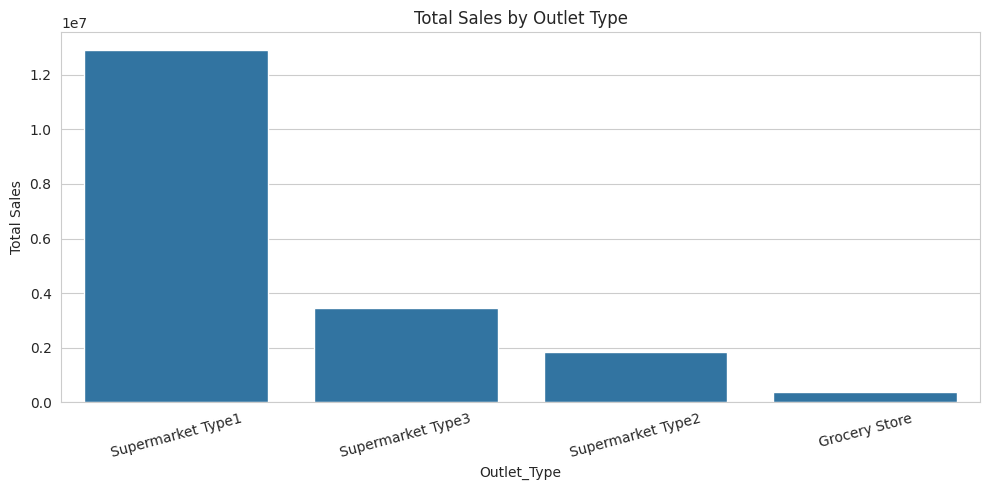

In [ ]:
outlet_type_sales = df.groupby('Outlet_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

# Step 2: Draw the bar chart
plt.figure()
sns.barplot(x=outlet_type_sales.index, y=outlet_type_sales.values)
plt.title('Total Sales by Outlet Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Graph 2: Average Sales by Outlet Size' (Q2)
 Question: Does outlet size affect sales performance?

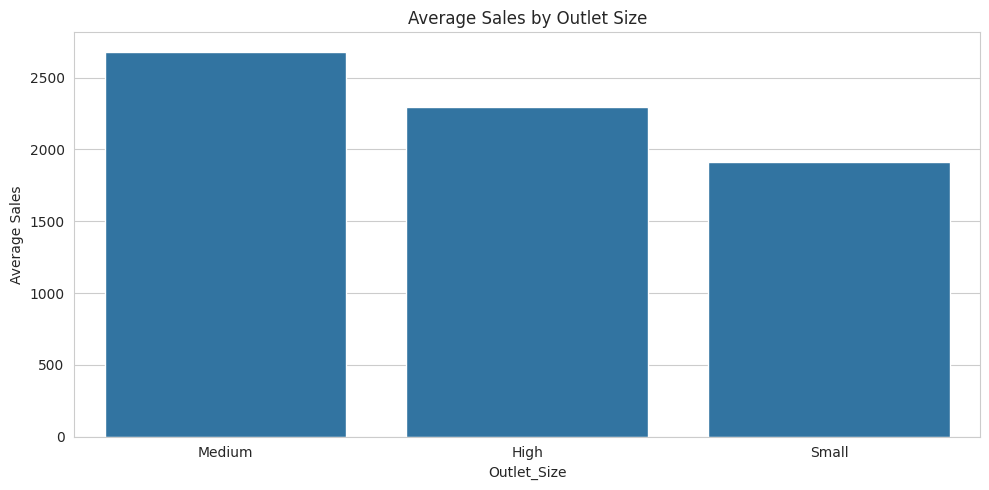

In [ ]:
# Group and calculate average sales by outlet size (same as Q2)
outlet_size_sales = df.groupby('Outlet_Size')['Item_Outlet_Sales'].mean().sort_values(ascending=False)

# Draw the bar chart
plt.figure()
sns.barplot(x=outlet_size_sales.index, y=outlet_size_sales.values)
plt.title('Average Sales by Outlet Size')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

 Graph 3: Total Sales by Location Tier. (Q3) Which location tier drives the most revenue?

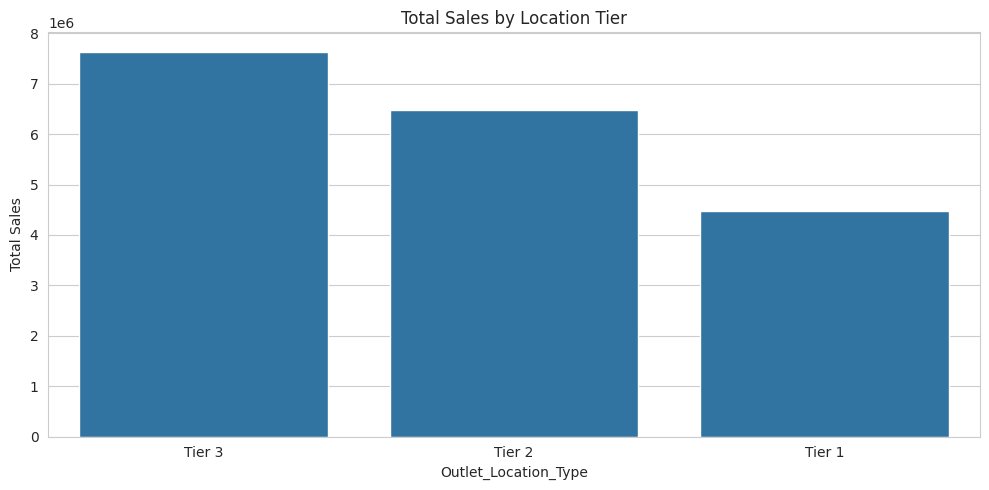

In [ ]:
#  Group and calculate total sales by location tier (same as Q3)
location_sales = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

# Draw the bar chart
plt.figure()
sns.barplot(x=location_sales.index, y=location_sales.values)
plt.title('Total Sales by Location Tier')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

Graph 4: Average Sales by Outlet Age .(Q4)
 Question: Do older outlets outperform newer ones?

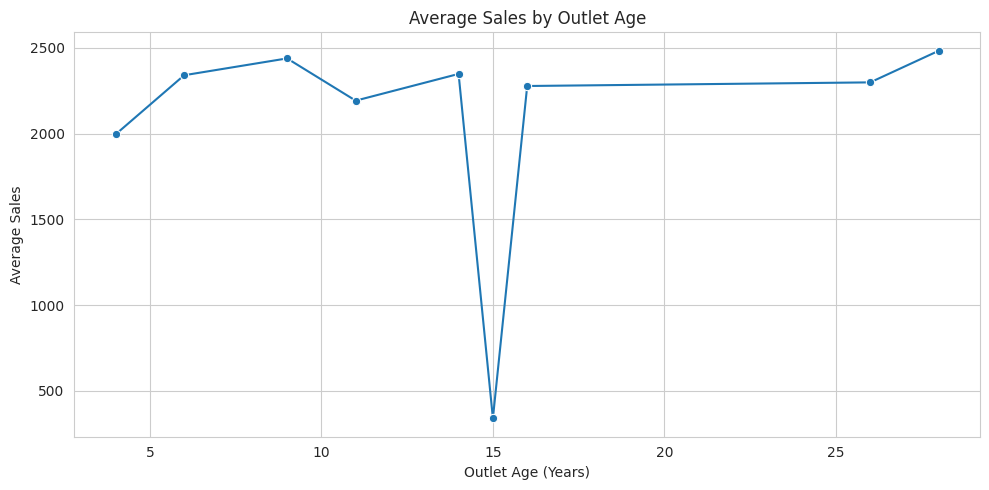

In [ ]:
# Group and calculate average sales by outlet age
# Create Outlet_Age from Outlet_Establishment_Year (if not already present)
if 'Outlet_Age' not in df.columns:
    df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']

# Group and calculate average sales by outlet age
age_sales = df.groupby('Outlet_Age')['Item_Outlet_Sales'].mean().sort_index()

#Draw the line chart
plt.figure()
sns.lineplot(x=age_sales.index, y=age_sales.values, marker='o')
plt.title('Average Sales by Outlet Age')
plt.xlabel('Outlet Age (Years)')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

 Graph 5: Total Sales by Item Type .(Q5) Which item types sell the most vs. least?

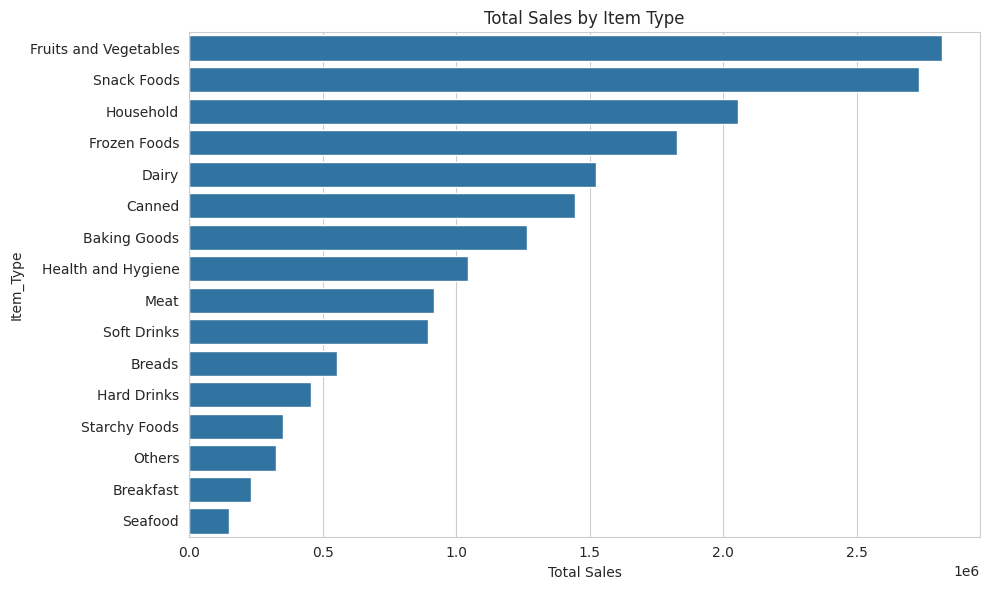

In [ ]:
# Group and calculate total sales by item type (same as Q5)
item_type_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

#Draw the horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(y=item_type_sales.index, x=item_type_sales.values)
plt.title('Total Sales by Item Type')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

 Graph 6: Item Visibility vs Sales .(Q6) Does item visibility correlate with higher sales?

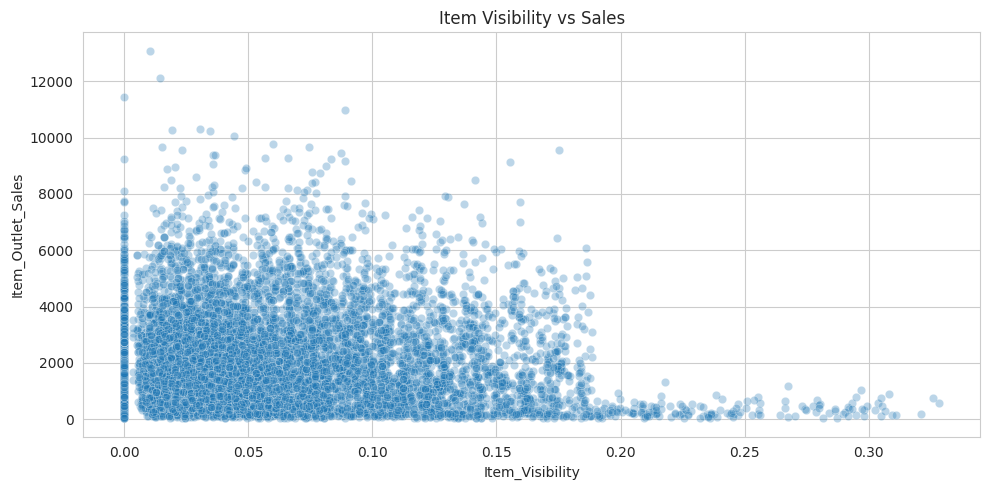

In [ ]:
plt.figure()
sns.scatterplot(x='Item_Visibility', y='Item_Outlet_Sales', data=df, alpha=0.3)
plt.title('Item Visibility vs Sales')
plt.tight_layout()
plt.show()

Graph 7: Item MRP vs Sales .(Q7)Does price correlate with sales?

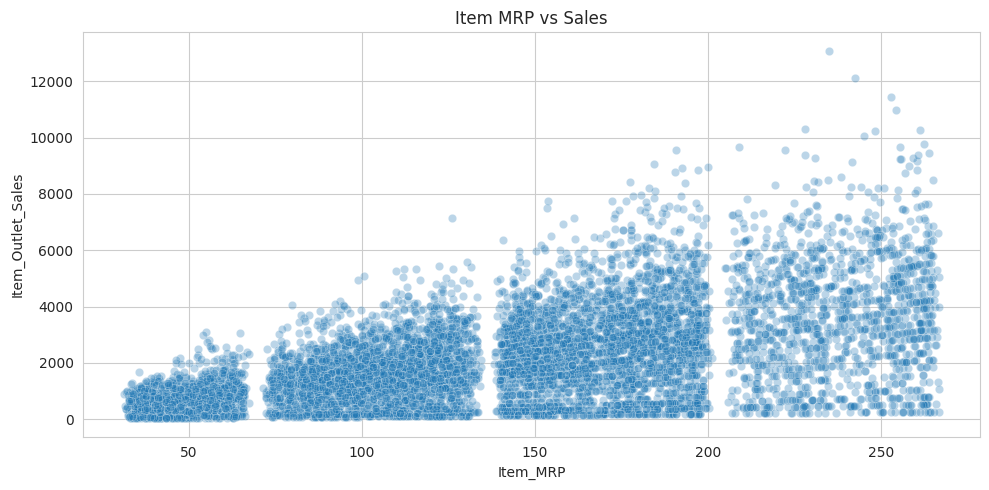

In [ ]:
plt.figure()
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df, alpha=0.3)
plt.title('Item MRP vs Sales')
plt.tight_layout()
plt.show()

Graph 8: Average Sales by Fat Content .(Q8)  Does fat content affect sales?

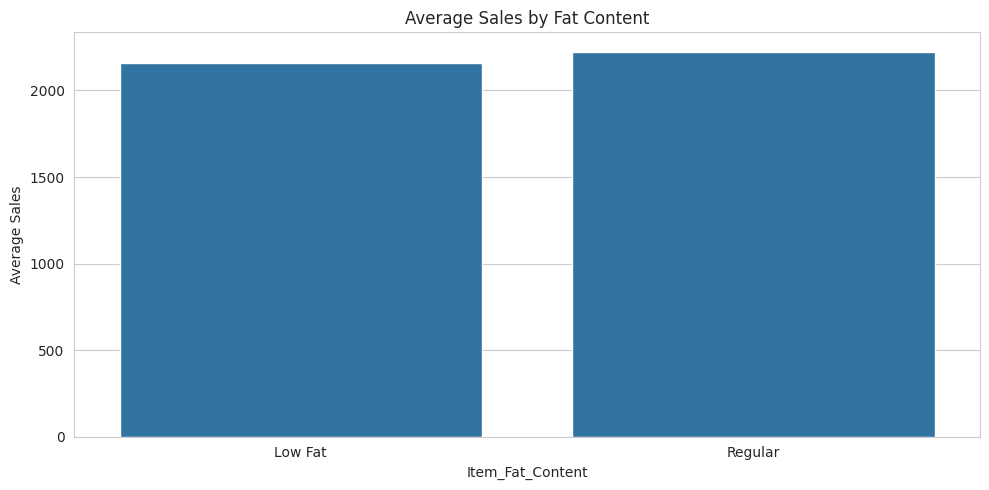

In [ ]:
# Clean the messy fat content labels
fat_map = {
    'low fat': 'Low Fat', 'LF': 'Low Fat', 'Low Fat': 'Low Fat',
    'reg': 'Regular', 'Regular': 'Regular'
}
df['Item_Fat_Content'] = df['Item_Fat_Content'].map(fat_map)

# Group and calculate average sales by fat content
fat_sales = df.groupby('Item_Fat_Content')['Item_Outlet_Sales'].mean()

#Draw the bar chart
plt.figure()
sns.barplot(x=fat_sales.index, y=fat_sales.values)
plt.title('Average Sales by Fat Content')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

 Graph 9: Total Sales by Outlet. (KPI 9)  How does total sales contribution vary across individual outlets?

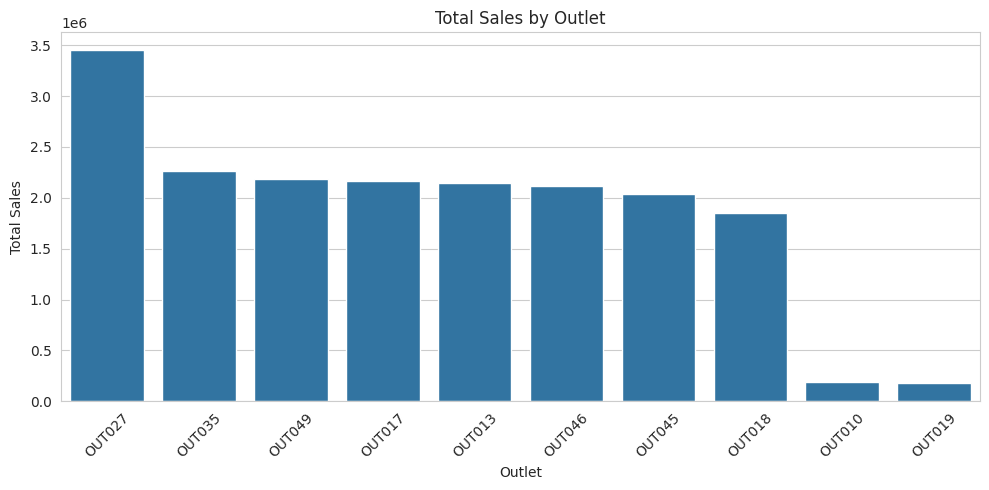

In [ ]:
# Group and calculate total sales for each individual outlet
outlet_sales = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].sum().sort_values(ascending=False)

# Draw the bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=outlet_sales.index, y=outlet_sales.values)
plt.title('Total Sales by Outlet')
plt.xlabel('Outlet')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Graph 10: Top Outlet Type + Item Type Combinations .(Q10) Which outlet type and item type combination sells the most?

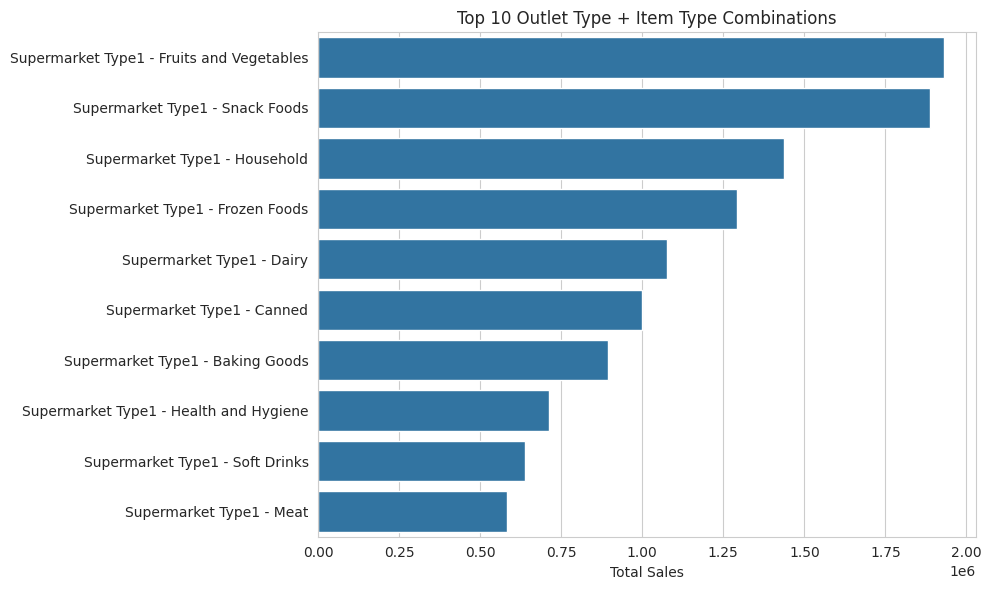

In [ ]:
#  Group by both Outlet_Type and Item_Type together, get total sales
combo = df.groupby(['Outlet_Type', 'Item_Type'])['Item_Outlet_Sales'].sum().sort_values(ascending=False)

#  Keep only the top 10 combinations
top_combo = combo.head(10)
 #Build readable labels like "Supermarket Type1 - Snack Foods"
labels = [f"{ot} - {it}" for ot, it in top_combo.index]

#  Draw the horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(y=labels, x=top_combo.values)
plt.title('Top 10 Outlet Type + Item Type Combinations')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()